In [1]:
import pyspark
from pyspark import SparkContext
from pyspark.sql import Row
from pyspark.sql import SQLContext
from pyspark import SparkFiles
import os
import pandas as pd

In [2]:
"""----------------------------------------------------------------------------
CREATE SPARK CONTEXT
CREATE SQL CONTEXT
----------------------------------------------------------------------------"""
sc =SparkContext()
sqlContext = SQLContext(sc)

/usr/local/lib/python3.9/dist-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/03/10 19:04:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/03/10 19:04:05 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/03/10 19:04:05 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
/usr/local/lib/python3.9/dist-packages/pyspark/sql/context.py:113: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


In [3]:
"""----------------------------------------------------------------------------
LOAD IRIS DATA
----------------------------------------------------------------------------"""
data_dir="/work/irlin355_1/gratienj/ParallelProgrammingCourse/BigDataHadoopSpark/TPs/data"
file = os.path.join("iris.csv")
panda_df = pd.read_csv(file)

iris_df=sqlContext.createDataFrame(panda_df)
iris_df.printSchema()

root
 |-- sepal_length: double (nullable = true)
 |-- sepal_width: double (nullable = true)
 |-- petal_length: double (nullable = true)
 |-- petal_width: double (nullable = true)
 |-- variety: string (nullable = true)



In [4]:
#Add a numeric indexer for the label/target column
from pyspark.ml.feature import StringIndexer
stringIndexer = StringIndexer(inputCol="variety", outputCol="ind_variety")
si_model = stringIndexer.fit(iris_df)
irisNormDf = si_model.transform(iris_df)
irisNormDf.printSchema()

root
 |-- sepal_length: double (nullable = true)
 |-- sepal_width: double (nullable = true)
 |-- petal_length: double (nullable = true)
 |-- petal_width: double (nullable = true)
 |-- variety: string (nullable = true)
 |-- ind_variety: double (nullable = false)



In [5]:
irisNormDf.select("variety","ind_variety").distinct().collect()
#irisNormDf.cache()

[Row(variety='Setosa', ind_variety=0.0),
 Row(variety='Versicolor', ind_variety=1.0),
 Row(variety='Virginica', ind_variety=2.0)]

In [6]:
"""--------------------------------------------------------------------------
Perform Data Analytics
-------------------------------------------------------------------------"""

#See standard parameters
irisNormDf.describe().show()

25/03/10 19:04:31 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+------------------+------------------+------------------+---------+------------------+
|summary|      sepal_length|       sepal_width|      petal_length|       petal_width|  variety|       ind_variety|
+-------+------------------+------------------+------------------+------------------+---------+------------------+
|  count|               150|               150|               150|               150|      150|               150|
|   mean| 5.843333333333334|3.0573333333333323|3.7579999999999996|1.1993333333333336|     NULL|               1.0|
| stddev|0.8280661279778636|0.4358662849366982| 1.765298233259466|0.7622376689603465|     NULL|0.8192319205190406|
|    min|               4.3|               2.0|               1.0|               0.1|   Setosa|               0.0|
|    max|               7.9|               4.4|               6.9|               2.5|Virginica|               2.0|
+-------+------------------+------------------+------------------+--------------

In [7]:
"""--------------------------------------------------------------------------
Prepare data for ML
-------------------------------------------------------------------------"""

#Transform to a Data Frame for input to Machine Learing
#Drop columns that are not required (low correlation)

from pyspark.ml.linalg import Vectors
def transformToLabeledPoint(row) :
    lp = ( row["variety"], row["ind_variety"], \
                Vectors.dense([row["sepal_length"],\
                        row["sepal_width"], \
                        row["petal_length"], \
                        row["petal_width"]]))
    return lp

irisLp = irisNormDf.rdd.map(transformToLabeledPoint)
irisLpDf = sqlContext.createDataFrame(irisLp,["species","label", "features"])
irisLpDf.select("species","label","features").show(50)
irisLpDf.cache()

+-------+-----+-----------------+
|species|label|         features|
+-------+-----+-----------------+
| Setosa|  0.0|[5.1,3.5,1.4,0.2]|
| Setosa|  0.0|[4.9,3.0,1.4,0.2]|
| Setosa|  0.0|[4.7,3.2,1.3,0.2]|
| Setosa|  0.0|[4.6,3.1,1.5,0.2]|
| Setosa|  0.0|[5.0,3.6,1.4,0.2]|
| Setosa|  0.0|[5.4,3.9,1.7,0.4]|
| Setosa|  0.0|[4.6,3.4,1.4,0.3]|
| Setosa|  0.0|[5.0,3.4,1.5,0.2]|
| Setosa|  0.0|[4.4,2.9,1.4,0.2]|
| Setosa|  0.0|[4.9,3.1,1.5,0.1]|
| Setosa|  0.0|[5.4,3.7,1.5,0.2]|
| Setosa|  0.0|[4.8,3.4,1.6,0.2]|
| Setosa|  0.0|[4.8,3.0,1.4,0.1]|
| Setosa|  0.0|[4.3,3.0,1.1,0.1]|
| Setosa|  0.0|[5.8,4.0,1.2,0.2]|
| Setosa|  0.0|[5.7,4.4,1.5,0.4]|
| Setosa|  0.0|[5.4,3.9,1.3,0.4]|
| Setosa|  0.0|[5.1,3.5,1.4,0.3]|
| Setosa|  0.0|[5.7,3.8,1.7,0.3]|
| Setosa|  0.0|[5.1,3.8,1.5,0.3]|
| Setosa|  0.0|[5.4,3.4,1.7,0.2]|
| Setosa|  0.0|[5.1,3.7,1.5,0.4]|
| Setosa|  0.0|[4.6,3.6,1.0,0.2]|
| Setosa|  0.0|[5.1,3.3,1.7,0.5]|
| Setosa|  0.0|[4.8,3.4,1.9,0.2]|
| Setosa|  0.0|[5.0,3.0,1.6,0.2]|
| Setosa|  0.0

DataFrame[species: string, label: double, features: vector]

In [8]:
"""--------------------------------------------------------------------------
Perform Machine Learning
-------------------------------------------------------------------------"""

#Split into training and testing data
(trainingData, testData) = irisLpDf.randomSplit([0.9, 0.1])
trainingData.count()
testData.count()
testData.collect()

[Row(species='Setosa', label=0.0, features=DenseVector([5.0, 3.4, 1.5, 0.2])),
 Row(species='Setosa', label=0.0, features=DenseVector([5.4, 3.7, 1.5, 0.2])),
 Row(species='Setosa', label=0.0, features=DenseVector([5.1, 3.5, 1.4, 0.3])),
 Row(species='Setosa', label=0.0, features=DenseVector([5.0, 3.0, 1.6, 0.2])),
 Row(species='Setosa', label=0.0, features=DenseVector([5.0, 3.5, 1.3, 0.3])),
 Row(species='Versicolor', label=1.0, features=DenseVector([5.6, 2.9, 3.6, 1.3])),
 Row(species='Versicolor', label=1.0, features=DenseVector([5.5, 2.4, 3.7, 1.0])),
 Row(species='Versicolor', label=1.0, features=DenseVector([5.7, 2.9, 4.2, 1.3])),
 Row(species='Versicolor', label=1.0, features=DenseVector([5.7, 3.0, 4.2, 1.2])),
 Row(species='Versicolor', label=1.0, features=DenseVector([6.2, 2.9, 4.3, 1.3])),
 Row(species='Virginica', label=2.0, features=DenseVector([7.2, 3.6, 6.1, 2.5])),
 Row(species='Virginica', label=2.0, features=DenseVector([7.3, 2.9, 6.3, 1.8])),
 Row(species='Virginica', 

In [9]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

#Create the model
dtClassifer = DecisionTreeClassifier(maxDepth=4, labelCol="label",\
                featuresCol="features")
dtModel = dtClassifer.fit(trainingData)

In [10]:
print(dtModel.numNodes)
print(dtModel.depth)

13
4


In [11]:
#Predict on the test data
predictions = dtModel.transform(testData)
predictions.select("prediction","species","label").collect()

[Row(prediction=0.0, species='Setosa', label=0.0),
 Row(prediction=0.0, species='Setosa', label=0.0),
 Row(prediction=0.0, species='Setosa', label=0.0),
 Row(prediction=0.0, species='Setosa', label=0.0),
 Row(prediction=0.0, species='Setosa', label=0.0),
 Row(prediction=1.0, species='Versicolor', label=1.0),
 Row(prediction=1.0, species='Versicolor', label=1.0),
 Row(prediction=1.0, species='Versicolor', label=1.0),
 Row(prediction=1.0, species='Versicolor', label=1.0),
 Row(prediction=1.0, species='Versicolor', label=1.0),
 Row(prediction=2.0, species='Virginica', label=2.0),
 Row(prediction=2.0, species='Virginica', label=2.0),
 Row(prediction=2.0, species='Virginica', label=2.0),
 Row(prediction=1.0, species='Virginica', label=2.0),
 Row(prediction=1.0, species='Virginica', label=2.0),
 Row(prediction=1.0, species='Virginica', label=2.0),
 Row(prediction=2.0, species='Virginica', label=2.0)]

In [12]:
#Evaluate accuracy
evaluator = MulticlassClassificationEvaluator(predictionCol="prediction", \
                    labelCol="label",metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print(f"Test Accuracy = {accuracy*100}")

Test Accuracy = 82.35294117647058


In [13]:
#Draw a confusion matrix
predictions.groupBy("label","prediction").count().show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|    5|
|  1.0|       1.0|    5|
|  2.0|       2.0|    4|
|  2.0|       1.0|    3|
+-----+----------+-----+



### A/ Spark ML : Iris classification

1/ Write a Spark Pipeline to transform and process the data before applying the machine learning 
process.

In [14]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier, OneVsRest

In [15]:
# split data
(trainingData, testData) = iris_df.randomSplit([0.9, 0.1])

In [16]:
testData.show()

+------------+-----------+------------+-----------+----------+
|sepal_length|sepal_width|petal_length|petal_width|   variety|
+------------+-----------+------------+-----------+----------+
|         5.1|        3.5|         1.4|        0.2|    Setosa|
|         5.1|        3.5|         1.4|        0.3|    Setosa|
|         5.1|        3.8|         1.5|        0.3|    Setosa|
|         5.2|        3.4|         1.4|        0.2|    Setosa|
|         5.2|        4.1|         1.5|        0.1|    Setosa|
|         6.5|        2.8|         4.6|        1.5|Versicolor|
|         6.3|        3.3|         4.7|        1.6|Versicolor|
|         5.9|        3.2|         4.8|        1.8|Versicolor|
|         6.6|        3.0|         4.4|        1.4|Versicolor|
|         5.5|        2.6|         4.4|        1.2|Versicolor|
|         5.6|        2.7|         4.2|        1.3|Versicolor|
|         5.8|        2.6|         4.0|        1.2|Versicolor|
|         6.0|        2.2|         5.0|        1.5| Vir

In [17]:
# Define the stages of the pipeline
indexer = StringIndexer(inputCol="variety", outputCol="label")
assembler = VectorAssembler(inputCols=["sepal_length", "sepal_width", "petal_length", "petal_width"], outputCol="features")
dtClassifier = DecisionTreeClassifier(maxDepth=4, labelCol="label", featuresCol="features")

# Create the pipeline
pipeline_dt = Pipeline(stages=[indexer, assembler, dtClassifier])

# Fit the pipeline to the training data
pipelineModel_dt = pipeline_dt.fit(trainingData)

# Make predictions on the test data
predictions_dt = pipelineModel_dt.transform(testData)

# Evaluate accuracy
evaluator = MulticlassClassificationEvaluator(predictionCol="prediction", labelCol="label", metricName="accuracy")
accuracy_dt = evaluator.evaluate(predictions_dt)
print(f"Test Accuracy = {accuracy_dt*100}")

# Compute confusion matrix
predictions_dt.groupBy("label", "prediction").count().show()

Test Accuracy = 88.23529411764706
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|    5|
|  2.0|       2.0|    6|
|  2.0|       1.0|    1|
|  1.0|       2.0|    1|
|  1.0|       1.0|    4|
+-----+----------+-----+



2/ Write two other versions of this test using :

• The Random Forest Classifier

In [18]:
# Define the Random Forest Classifier
rfClassifier = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=4)

# Create the pipeline with Random Forest
pipeline_rf = Pipeline(stages=[indexer, assembler, rfClassifier])

# Fit the pipeline to the training data
pipelineModel_rf = pipeline_rf.fit(trainingData)

# Make predictions on the test data
predictions_rf = pipelineModel_rf.transform(testData)

# Evaluate accuracy
accuracy_rf = evaluator.evaluate(predictions_rf)
print(f"Random Forest Test Accuracy = {accuracy_rf*100}")

# Compute confusion matrix
predictions_rf.groupBy("label", "prediction").count().show()

Random Forest Test Accuracy = 88.23529411764706
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|    5|
|  2.0|       2.0|    6|
|  2.0|       1.0|    1|
|  1.0|       2.0|    1|
|  1.0|       1.0|    4|
+-----+----------+-----+



• The Gradient Boosted Tree Classifier (transform the binary Classifier in a multi-class 
classifier using a tree classifier : for (A,B,C,D,…) classes, use ( A, not A), (B, not B), (C, 
not C), (D, not D),... binalry classifiers.

In [19]:
# Define the Gradient Boosted Tree Classifier
gbtClassifier = GBTClassifier(labelCol="label", featuresCol="features", maxIter=4)
ovr = OneVsRest(classifier=gbtClassifier)

# Create the pipeline with Gradient Boosted Tree
pipeline_gbt = Pipeline(stages=[indexer, assembler, ovr])

# Fit the pipeline to the training data
pipelineModel_gbt = pipeline_gbt.fit(trainingData)

# Make predictions on the test data
predictions_gbt = pipelineModel_gbt.transform(testData)

# Evaluate accuracy
accuracy_gbt = evaluator.evaluate(predictions_gbt)
print(f"Gradient Boosted Tree Test Accuracy = {accuracy_gbt*100}")

# Compute confusion matrix
predictions_gbt.groupBy("label", "prediction").count().show()

25/03/10 19:05:15 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Gradient Boosted Tree Test Accuracy = 88.23529411764706
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|    5|
|  2.0|       2.0|    6|
|  2.0|       1.0|    1|
|  1.0|       2.0|    1|
|  1.0|       1.0|    4|
+-----+----------+-----+



Compare the performance of the three machine learning models.

In [20]:
print(f"Decision Tree Test Accuracy = {accuracy_dt*100}")
print(f"Random Forest Test Accuracy = {accuracy_rf*100}")
print(f"Gradient Boosted Tree Test Accuracy = {accuracy_gbt*100}")

# Compute confusion matrix
print("Decision Tree Confusion Matrix:")
predictions_dt.groupBy("label", "prediction").count().show()

print("Random Forest Confusion Matrix:")
predictions_rf.groupBy("label", "prediction").count().show()

print("Gradient Boosted Tree Confusion Matrix:")
predictions_gbt.groupBy("label", "prediction").count().show()

Decision Tree Test Accuracy = 88.23529411764706
Random Forest Test Accuracy = 88.23529411764706
Gradient Boosted Tree Test Accuracy = 88.23529411764706
Decision Tree Confusion Matrix:
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|    5|
|  2.0|       2.0|    6|
|  2.0|       1.0|    1|
|  1.0|       2.0|    1|
|  1.0|       1.0|    4|
+-----+----------+-----+

Random Forest Confusion Matrix:
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|    5|
|  2.0|       2.0|    6|
|  2.0|       1.0|    1|
|  1.0|       2.0|    1|
|  1.0|       1.0|    4|
+-----+----------+-----+

Gradient Boosted Tree Confusion Matrix:


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|    5|
|  2.0|       2.0|    6|
|  2.0|       1.0|    1|
|  1.0|       2.0|    1|
|  1.0|       1.0|    4|
+-----+----------+-----+



In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(cm, title, ax):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Confusion Matrix: {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

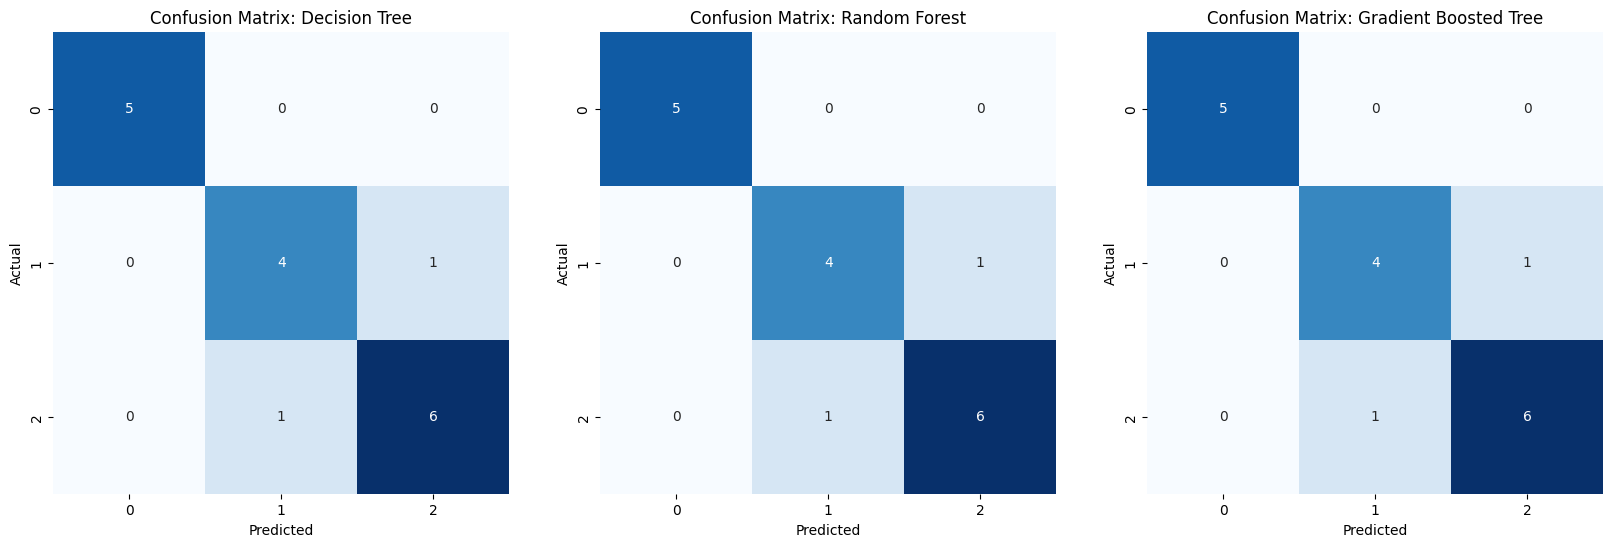

In [22]:
# Extract the true labels and predictions for three different models or datasets
y_true1 = [row['label'] for row in predictions_dt.select("label").collect()]
y_pred1 = [row['prediction'] for row in predictions_dt.select("prediction").collect()]

y_true2 = [row['label'] for row in predictions_rf.select("label").collect()]
y_pred2 = [row['prediction'] for row in predictions_rf.select("prediction").collect()]

y_true3 = [row['label'] for row in predictions_gbt.select("label").collect()]
y_pred3 = [row['prediction'] for row in predictions_gbt.select("prediction").collect()]

# Compute confusion matrices
cm1 = confusion_matrix(y_true1, y_pred1)
cm2 = confusion_matrix(y_true2, y_pred2)
cm3 = confusion_matrix(y_true3, y_pred3)

# Create subplots for side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_confusion_matrix(cm1, "Decision Tree", axes[0])
plot_confusion_matrix(cm1, "Random Forest", axes[1])
plot_confusion_matrix(cm1, "Gradient Boosted Tree", axes[2])

### B/ Dask ML : Iris classification

1/ Write a Dask Pipeline to transform and process the data before applying the machine learning 
process.

In [23]:
import dask.dataframe as dd
from dask_ml.preprocessing import LabelEncoder, StandardScaler
from dask_ml.model_selection import train_test_split
from dask_ml.wrappers import ParallelPostFit
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from dask_ml.metrics import accuracy_score
import time

In [24]:
# Load data
iris_df = dd.read_csv("iris.csv")

# Encode labels (variety column as 'label')
label_encoder = LabelEncoder()
iris_df['label'] = label_encoder.fit_transform(iris_df['variety'])

# Define features and labels
features = iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
labels = iris_df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.1, random_state=42)

# Standardize features
scaler = StandardScaler()

/usr/local/lib/python3.9/dist-packages/dask/dataframe/core.py:3769: UserWarning: Dask currently has limited support for converting pandas extension dtypes to arrays. Converting string to object dtype.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/dask_ml/model_selection/_split.py:464: FutureWarning: The default value for 'shuffle' must be specified when splitting DataFrames. In the future DataFrames will automatically be shuffled within blocks prior to splitting. Specify 'shuffle=True' to adopt the future behavior now, or 'shuffle=False' to retain the previous behavior.
  warnings.warn(


2/ Write two other versions of this test using :
• The Random Forest Classifier ;
• The Gradient Boosted Tree Classifier.

In [25]:
# Define classifiers
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=20, random_state=42)
gbt = GradientBoostingClassifier(n_estimators=20, random_state=42)

In [26]:
# Create pipelines for each model
pipeline_dt = make_pipeline(scaler, dt)
pipeline_rf = make_pipeline(scaler, rf)
pipeline_gbt = make_pipeline(scaler, gbt)

In [27]:
# Wrap models for parallel prediction with Dask
model_dt = ParallelPostFit(estimator=pipeline_dt)
model_rf = ParallelPostFit(estimator=pipeline_rf)
model_gbt = ParallelPostFit(estimator=pipeline_gbt)

In [28]:
# Train and evaluate each model
def train_and_evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred), y_pred

In [29]:
acc_dt, y_pred_dt = train_and_evaluate(model_dt, X_train, X_test, y_train, y_test)
acc_rf, y_pred_rf = train_and_evaluate(model_rf, X_train, X_test, y_train, y_test)
acc_gbt, y_pred_gbt = train_and_evaluate(model_gbt, X_train, X_test, y_train, y_test)

# Print results
print(f"Decision Tree - Accuracy: {acc_dt*100}")
print(f"Random Forest - Accuracy: {acc_rf*100}")
print(f"Gradient Boosted Tree - Accuracy: {acc_gbt*100}")

/usr/local/lib/python3.9/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(


Decision Tree - Accuracy: 100.0
Random Forest - Accuracy: 100.0
Gradient Boosted Tree - Accuracy: 100.0


/usr/local/lib/python3.9/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(


Compare the performance of the three machine learning models.

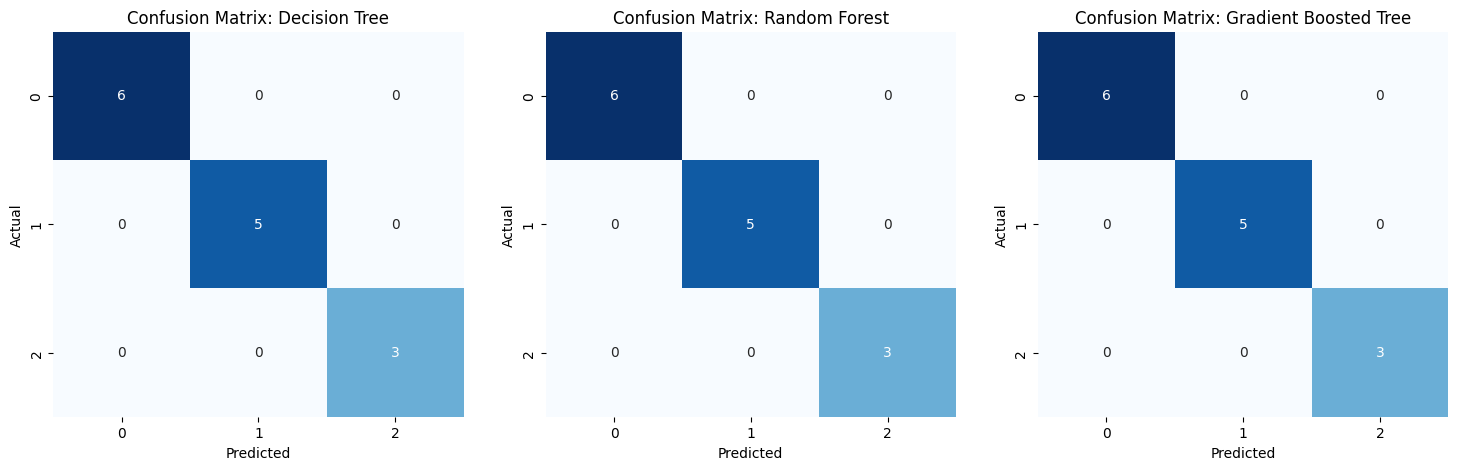

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_dt = confusion_matrix(y_test.compute(), y_pred_dt.compute()) 
plot_confusion_matrix(cm_dt, "Decision Tree", axes[0])
cm_rf = confusion_matrix(y_test.compute(), y_pred_rf.compute()) 
plot_confusion_matrix(cm_rf, "Random Forest", axes[1])
cm_gbt = confusion_matrix(y_test.compute(), y_pred_gbt.compute()) 
plot_confusion_matrix(cm_gbt, "Gradient Boosted Tree", axes[2])